# 10. Loop comp

Part of the **[Fig. 4 chapter](fig4.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{compdir}bin_stats.hdf'`  ·  _other_
- `f'{compdir}DifferentialResult/fdr_result/differential.intra_sample_combined.pcQnm.bedGraph'`  ·  _other_
- `f'{loopdir}loop_Q.hdf'`  ·  _loop calls_
- `f'{loopdir}loop_T.hdf'`  ·  _loop calls_
- `f'{loopdir}merged_loop.hdf'`  ·  _loop calls_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

[repro_guard] active — READ-ONLY (all writes skipped; inline figures still render)


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm as cm
from scipy.stats import zscore, pearsonr, norm
from sklearn.cluster import KMeans
import matplotlib.patches as patches

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [3]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/loop_compartment/'
compdir = f'{indir}analysis/diff_comp/all/'
loopdir = f'{indir}analysis/diff_loop/all/'


In [4]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
leg = L1_meta.index
res = 100000
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [5]:
binall = pd.read_hdf(f'{compdir}bin_stats.hdf', key='data')
comp = pd.read_csv(f'{compdir}DifferentialResult/fdr_result/differential.intra_sample_combined.pcQnm.bedGraph', sep='\t', header=0, index_col=None)
comp.index = comp['chr'] + '_' + (comp['start'] // res).astype(str)
comp = comp.loc[binall.index, leg]


In [6]:
loopq = pd.read_hdf(f'{loopdir}loop_Q.hdf', key='data')
loopt = pd.read_hdf(f'{loopdir}loop_T.hdf', key='data')
loopall = pd.read_hdf(f'{loopdir}merged_loop.hdf', key='data')
leg = loopq.columns
print(loopall.shape, loopq.shape, loopt.shape)

(3154101, 12) (3154101, 35) (3154101, 35)


In [7]:
from scipy.stats import f
from statsmodels.sandbox.stats.multicomp import multipletests as FDR
    
def stats2fdr(data):
    pv = [f.sf(x, nct-1, ncell-nct) for x in data.values]
    fdr = FDR(pv, 0.01, "fdr_bh")[1]
    return fdr


In [8]:
nct = 35
ncell = 86689


In [9]:
from concurrent.futures import ProcessPoolExecutor, as_completed
cpu = 3
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for m in 'QET':
        future = executor.submit(
            stats2fdr,
            loopall[f'{m}anova']
        )
        futures[future] = m

    # result = []
    for future in as_completed(futures):
        m = futures[future]
        loopall[f'{m}fdr'] = future.result()
        print(f'{m} finished')
        

E finished


T finished


Q finished


In [10]:
loopall.to_hdf(f'{loopdir}merged_loop.hdf', key='data')


In [11]:
# sell = (loopall['Qanova']==0) | (loopall['Eanova']==0) | (loopall['Tanova']==0)
# loopall = loopall.loc[~sell]
# loopq = loopq.loc[~sell, leg]
# loopt = loopt.loc[~sell, leg]
# print(loopall.shape)


In [12]:
thres1 = norm.isf(0.025)
thres2 = norm.isf(0.15)
print(thres1, thres2)


1.9599639845400545 1.0364333894937898


In [13]:
fdrthres = 0.01
statfilter = (zscore(np.log10(loopall['Qanova']))>thres2) & (zscore(np.log10(loopall['Tanova']))>thres2)
fdrfilter = (loopall['Qfdr']<fdrthres) & (loopall['Efdr']<fdrthres) & (loopall['Tfdr']<fdrthres)
selloop = statfilter & fdrfilter
print(statfilter.sum(), fdrfilter.sum(), selloop.sum())


288656 3043481 288656


In [14]:
# selb = ((zscore(loopall['Qanova'])>thres2) & (zscore(loopall['Tanova'])>thres2))
# print(selb.sum())
selb = ((zscore(np.log10(loopall['Qanova']))>thres2) & (zscore(np.log10(loopall['Tanova']))>thres2))
print(selb.sum())


288656


In [15]:
# tmpq = loopq.loc[selb].values
# tmpq = zscore(tmpq, axis=1)
# tmpt = loopt.loc[selb].values
# tmpt = zscore(tmpt, axis=1)


## Differential Loop vs All Gene TSS

In [16]:
resc = 100000
loopall = loopall.loc[selb]
anchor1 = loopall[0] + '_' + (loopall[1] // resc).astype(str)
anchor2 = loopall[0] + '_' + (loopall[4] // resc).astype(str)


In [17]:
sell = anchor1.isin(comp.index) & anchor2.isin(comp.index)
loopall = loopall.loc[sell]
anchor1 = anchor1.loc[sell]
anchor2 = anchor2.loc[sell]


In [18]:
looptmp = zscore(loopq.loc[loopall.index].values, axis=1)


In [19]:
compall = (comp.loc[anchor1].values + comp.loc[anchor2].values) / 2
comptmp = zscore(compall, axis=1)


In [20]:
def order_row(data, nc):
    data = data.reset_index(drop=True)
    
    # Perform KMeans clustering    
    kmeans = KMeans(n_clusters=nc, random_state=0, n_init=10)
    clusters = kmeans.fit_predict(data)

    # Create a new dataframe with cluster labels
    cluster_df = pd.DataFrame({'Cluster': clusters}, index=data.index)

    # Sort the data by cluster and plot the heatmap
    merged_data = pd.concat([data, cluster_df], axis=1).groupby(by='Cluster').mean()
    cg = sns.clustermap(merged_data, cmap='vlag', metric='cosine', figsize=(6,4))
    
    rorder = cg.dendrogram_row.reordered_ind.copy()
    corder = cg.dendrogram_col.reordered_ind.copy()
    
    leg = merged_data.index[rorder]
    count = pd.Series(clusters).value_counts().loc[leg]
    sorted_data = pd.concat([data[clusters==i] for i in leg], axis=0)
    
    return sorted_data, count, cluster_df, corder


In [21]:
nc = 10
group_palette = sns.color_palette('Set3', nc)
tmp, count, label3c, corder = order_row(pd.DataFrame(looptmp), nc=nc)


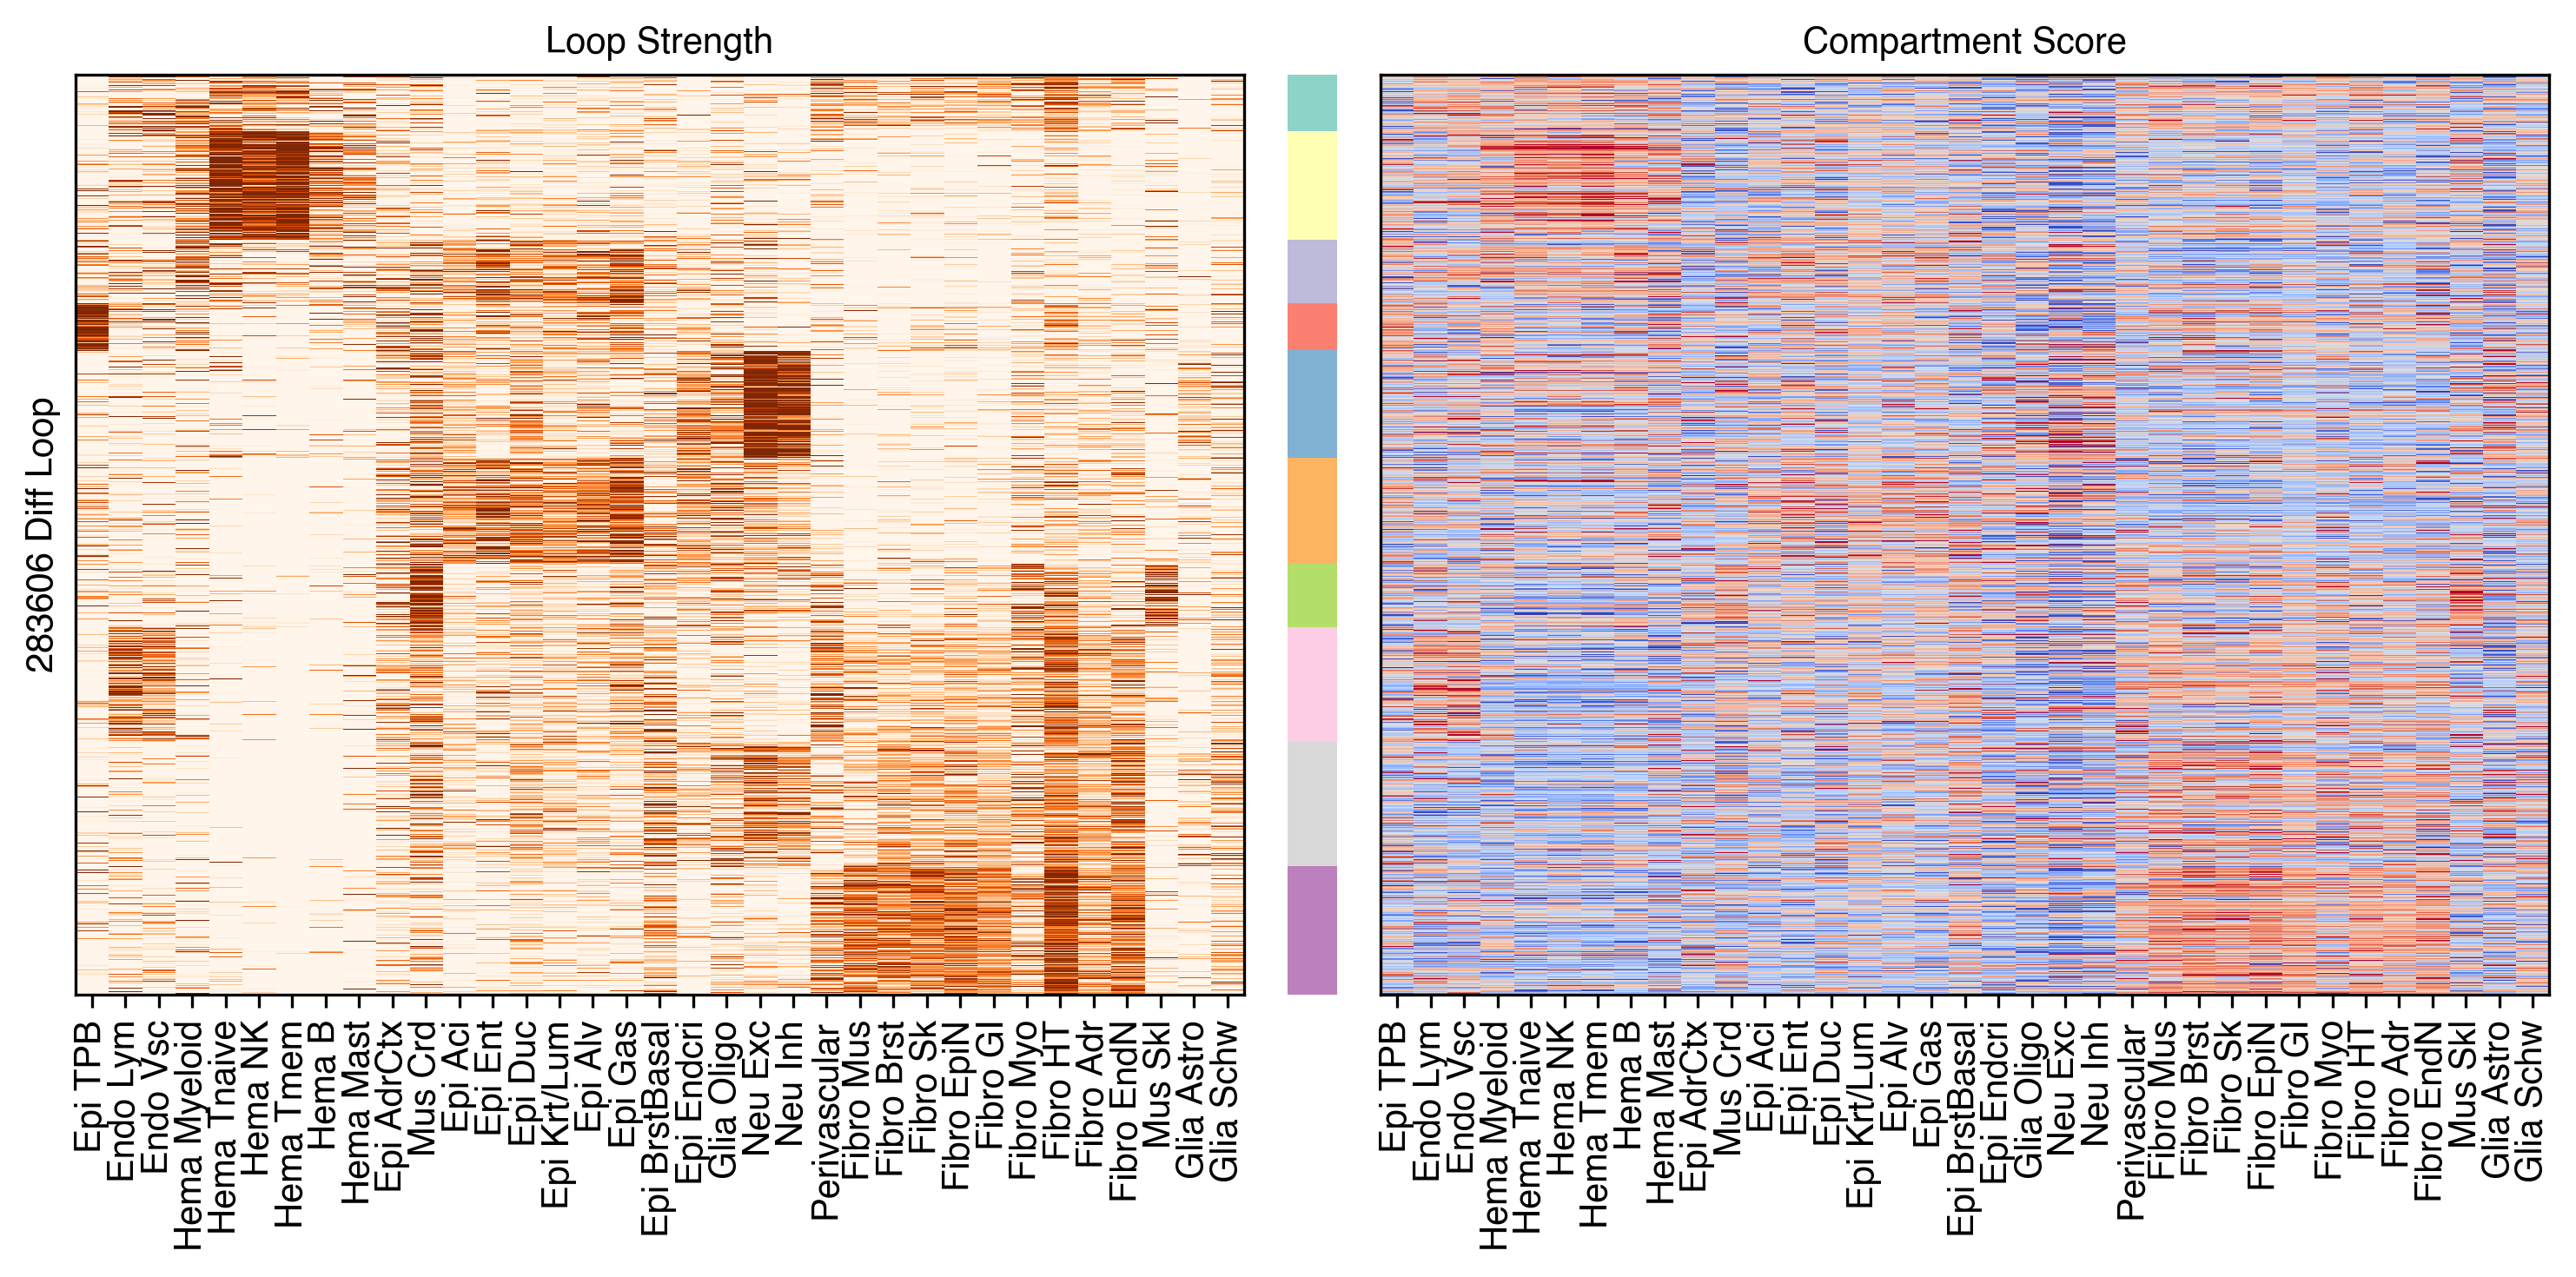

In [22]:
fig, axes = plt.subplots(1, 3, sharey='all', figsize=(10,5), dpi=300, 
                         gridspec_kw={'width_ratios': [12, 0.5, 12]})

ax = axes[0]
ax.imshow(tmp.values[:, corder], cmap='Oranges', aspect='auto', 
          interpolation='none', rasterized=True, vmin=0, vmax=2)
ax.set_title('Loop Strength', fontsize=10)
ax.set_xticks(np.arange(len(leg)))
ax.set_xticklabels(leg[corder].map(L1_annot), rotation=90)
ax.set_yticks([])
ax.set_ylabel(f'{looptmp.shape[0]} Diff Loop')

ax = axes[2]
ax.imshow(comptmp[np.ix_(tmp.index, corder)], cmap='coolwarm', vmin=-2, vmax=2, 
          aspect='auto', interpolation='none', rasterized=True)
ax.set_title('Compartment Score', fontsize=10)
ax.set_xticks(np.arange(len(leg)))
ax.set_xticklabels(leg[corder].map(L1_annot), rotation=90)

ax = axes[1]
offset = [0] + list(count.cumsum())
ax.axis('off')
for k in range(nc):
    rect = patches.Rectangle((0, offset[k]), 1, offset[k+1]-offset[k], linewidth=0, 
                             edgecolor='none', facecolor=group_palette[k])
    ax.add_patch(rect)

fig.tight_layout()
fig.savefig(f'{outdir}majortype_diffloop_comp.pdf', transparent=True)


In [23]:
np.random.seed(0)
sel = np.random.choice(np.arange(len(looptmp)), 2000, False)

cg = sns.clustermap(looptmp[sel], cmap='bwr', vmin=-3, vmax=3, metric='cosine', xticklabels=leg.map(L1_annot), yticklabels=[], figsize=(6,6))

rorder = cg.dendrogram_row.reordered_ind.copy()
corder = cg.dendrogram_col.reordered_ind.copy()


/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


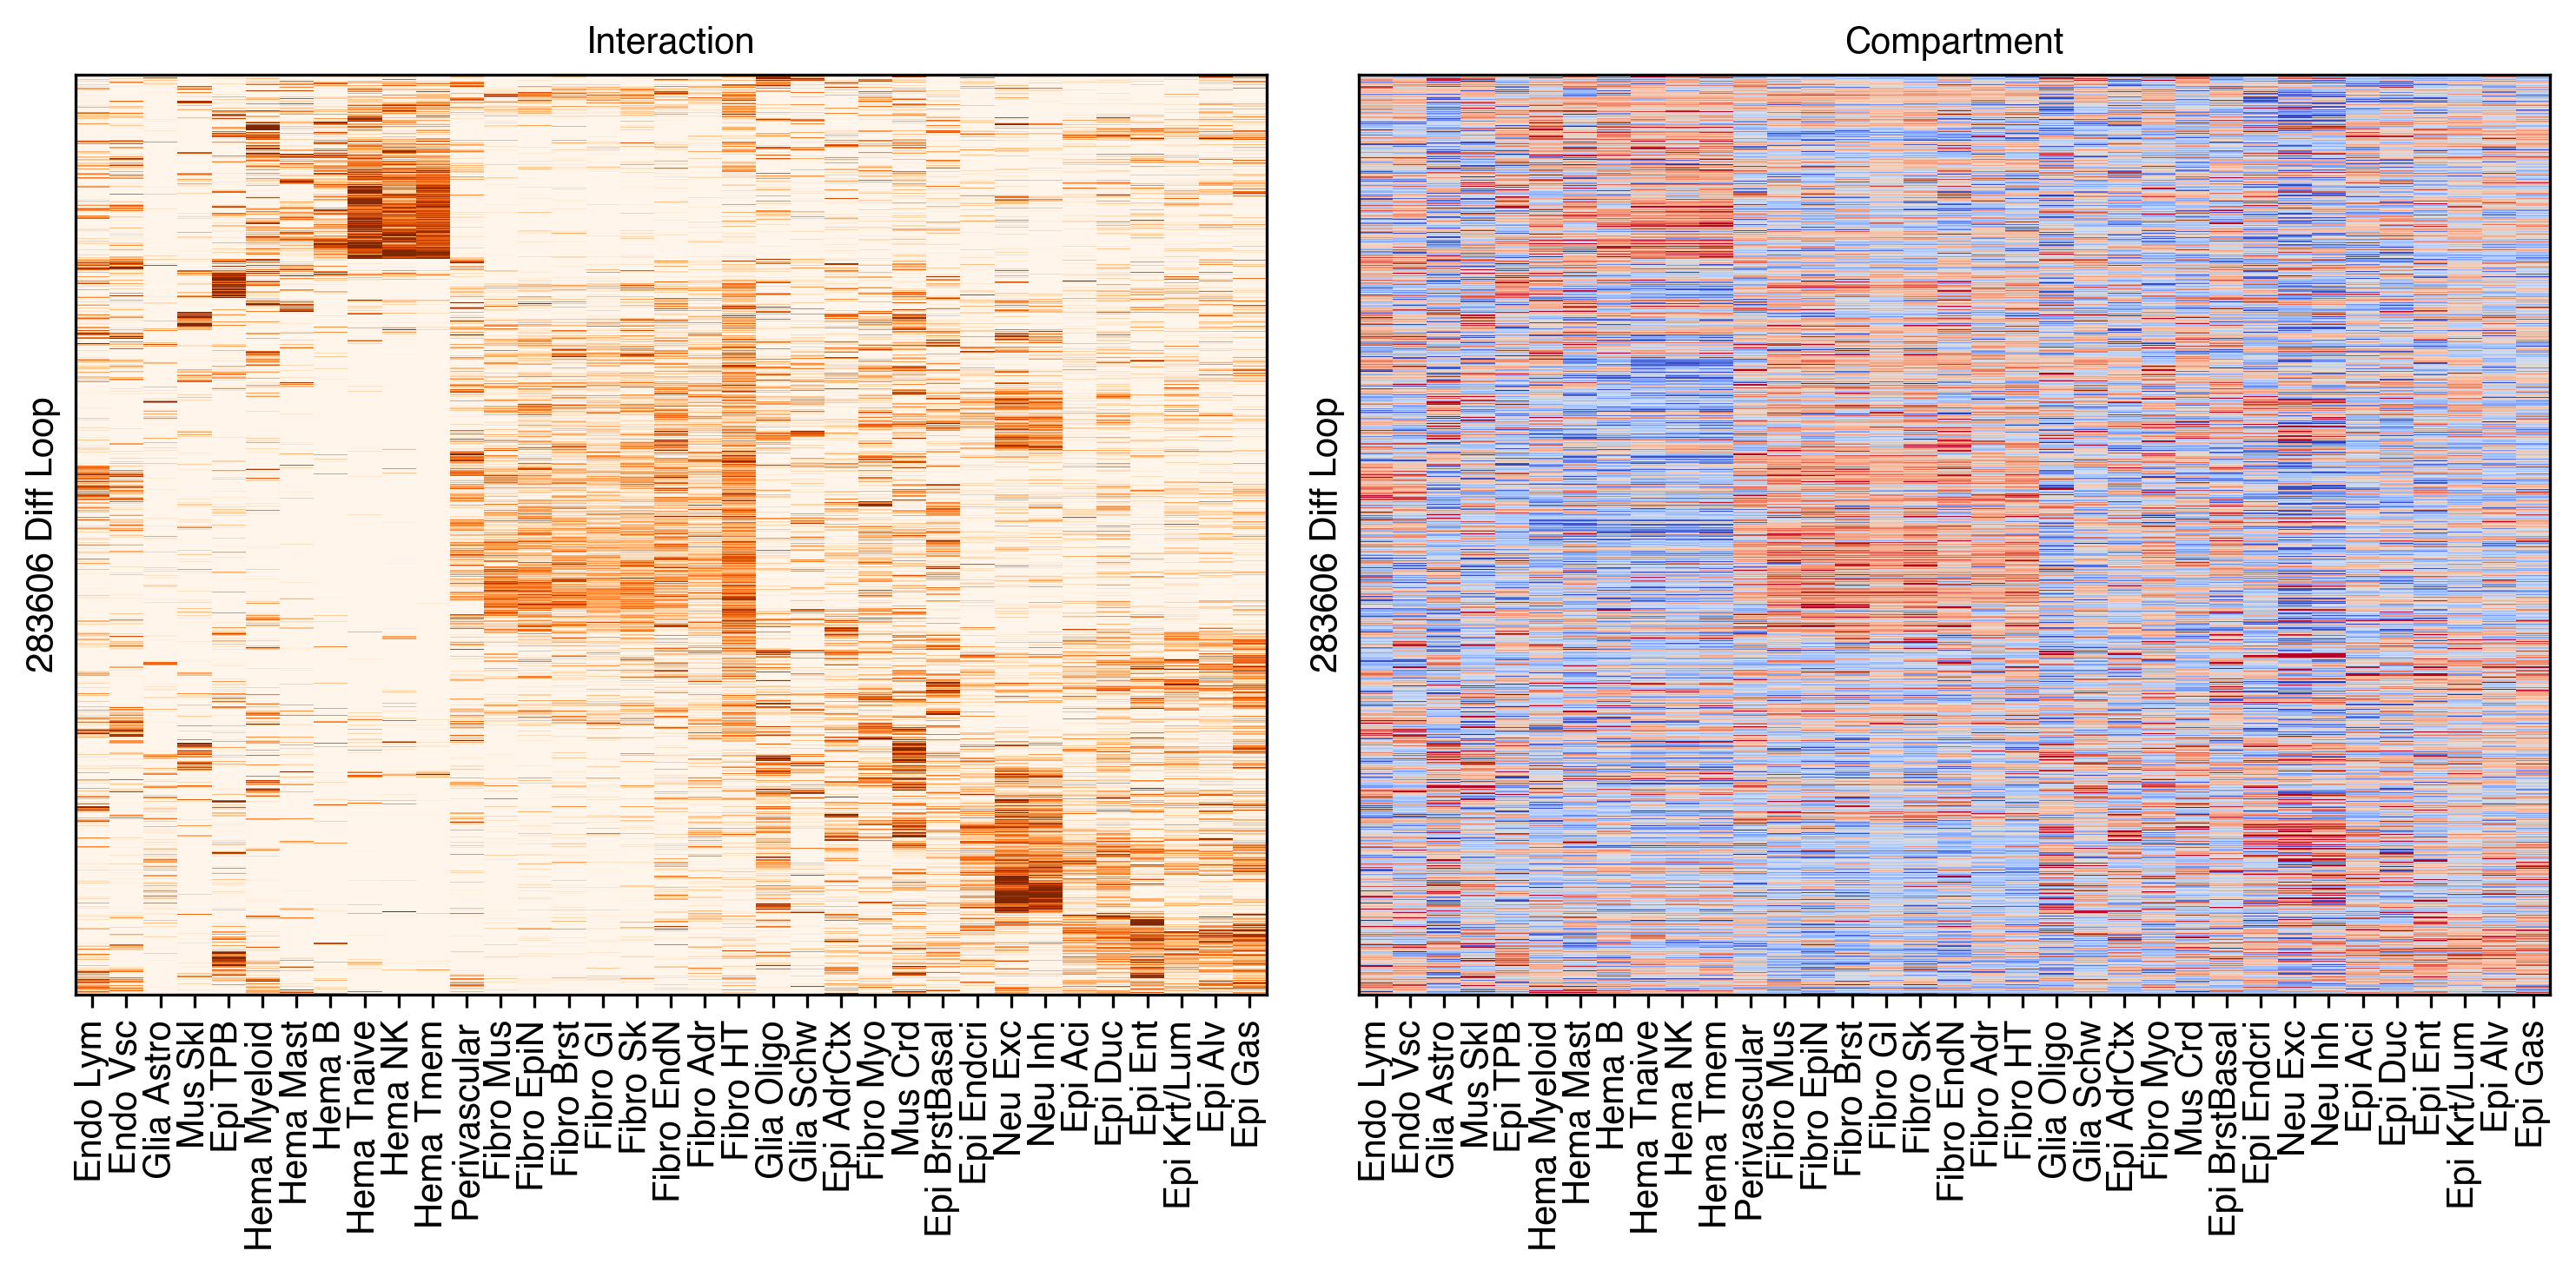

In [24]:
fig, axes = plt.subplots(1, 2, sharey='all', figsize=(10,5), dpi=300)

ax = axes[0]
ax.imshow(looptmp[np.ix_(sel[rorder], corder)], cmap='Oranges', vmin=0, vmax=3, 
          aspect='auto', interpolation='none', rasterized=True)
ax.set_title('Interaction', fontsize=10)
# sns.despine(ax=ax, left=True, bottom=True)
ax.set_xticks(np.arange(len(leg)))
ax.set_xticklabels(leg[corder].map(L1_annot), rotation=90)
ax.set_yticks([])
ax.set_ylabel(f'{looptmp.shape[0]} Diff Loop')

ax = axes[1]
ax.imshow(comptmp[np.ix_(sel[rorder], corder)], cmap='coolwarm', vmin=-2, vmax=2, 
          aspect='auto', interpolation='none', rasterized=True)
ax.set_title('Compartment', fontsize=10)
# sns.despine(ax=ax, left=True, bottom=True)
ax.set_xticks(np.arange(len(leg)))
ax.set_xticklabels(leg[corder].map(L1_annot), rotation=90)
ax.set_ylabel(f'{looptmp.shape[0]} Diff Loop')

fig.tight_layout()
fig.savefig(f'{outdir}majortype_diffloop_comp.pdf', transparent=True)
